# Tree example: training controls, a valid warm start, and ELBO diagnostics

Select the **cebmf** kernel and **Restart Kernel and Run All**. The default is a
small single-seed check. Set `QUICK=False` for ten simulations with 1,000 rows and
200 columns. All simulation and fitting code is below; no external files are read.

This corrects the repeated leaf mask, gaps in the sample groups, overwritten warm
start, double-appended result list and product-of-marginal-means reconstruction in
the original snippet. Both arms use the same final prior by default. To reproduce
the original *different-family* comparison, set `COLD_PRIOR="spiked_emdn"`.

In [1]:
import time
import torch
import matplotlib.pyplot as plt
from cebmf_torch import cEBMF

QUICK = True
N, P = (300, 80) if QUICK else (1000, 200)
SEEDS = [1] if QUICK else list(range(1, 11))
K = 6
NOISE_SD = 1.25
COLD_PRIOR = "cgb_sharp_2"
FINAL_PRIOR = "cgb_sharp_2"
COLD_ROUNDS, WARMUP_ROUNDS, WARM_ROUNDS = (4, 3, 4) if QUICK else (30, 10, 20)

PRIOR_SETTINGS = dict(penalty=1.1, n_epochs=4 if QUICK else 10, batch_size=256)
SAMPLER_SETTINGS = dict(
    initialization_iterations=3 if QUICK else 10,
    sweeps_per_round=4 if QUICK else 10,
    burnin=40 if QUICK else 100,
    draws=60 if QUICK else 200,
    thin=1,
    elbo_draws=32 if QUICK else 64,
    progress_every=0,
)
torch.set_num_threads(1)

## 1. Simulate, fit cold, fit CGB, then fit from the CGB starting point

`penalty` regularizes each learned spike probability. `n_epochs` is the number
of passes through the saved joint (draw, sample) pairs in a learning round;
`batch_size` controls their mini-batches. The penalty also enters the parent
correction, so learning and sampling use the same regularized target.

The valid warm-start call is `initialise_factors(L=..., F=...)`. Its rank must
match the supplied matrices. Copying slices after ordinary initialization would
allow the preliminary fit to overwrite the intended starting point.

In [2]:
cold_results, warm_results = [], []
cold_rmse, warm_rmse = [], []

for seed in SEEDS:
    started = time.perf_counter()
    rng = torch.Generator().manual_seed(seed)
    masks = torch.randint(0, 2, (7, P), generator=rng).double()
    F_true = masks * torch.randn(7, P, generator=rng, dtype=torch.float64)
    L_true = torch.zeros(N, 7, dtype=torch.float64)
    a, b, c = N // 4, N // 2, 3 * N // 4
    L_true[:, 0] = 1
    L_true[:b, 1] = 1
    L_true[b:, 2] = 1
    L_true[:a, 3] = 1
    L_true[a:b, 4] = 1
    L_true[b:c, 5] = 1
    L_true[c:, 6] = 1
    X_true = L_true @ F_true
    Z = X_true + NOISE_SD * torch.randn(N, P, generator=rng, dtype=torch.float64)

    cold_model = cEBMF(
        data=Z, K=K, prior_L=COLD_PRIOR, prior_F="norm", self_row_cov=True,
        S=NOISE_SD, device="cpu", allow_backfitting=True,
        prior_L_kwargs={**PRIOR_SETTINGS, "omega": 0.01},
        joint_kwargs={**SAMPLER_SETTINGS, "seed": seed + 100},
    )
    cold_model.initialise_factors()
    cold = cold_model.fit(COLD_ROUNDS)

    source_model = cEBMF(
        data=Z, K=K, prior_L="cgb", prior_F="norm", self_row_cov=True,
        S=NOISE_SD, device="cpu", allow_backfitting=True,
        prior_L_kwargs=PRIOR_SETTINGS,
        joint_kwargs={**SAMPLER_SETTINGS, "seed": seed + 200},
    )
    source_model.initialise_factors()
    source = source_model.fit(WARMUP_ROUNDS)

    warm_model = cEBMF(
        data=Z, K=source.L.shape[1], prior_L=FINAL_PRIOR, prior_F="norm",
        self_row_cov=True, S=NOISE_SD, device="cpu", allow_backfitting=True,
        prior_L_kwargs={**PRIOR_SETTINGS, "omega": 0.01},
        joint_kwargs={**SAMPLER_SETTINGS, "seed": seed + 300},
    )
    warm_model.initialise_factors(L=source.L.detach().clone(), F=source.F.detach().clone())
    warm = warm_model.fit(WARM_ROUNDS)

    cold_results.append(cold)
    warm_results.append(warm)
    cold_rmse.append((X_true - cold.reconstruction).square().mean().sqrt().item())
    warm_rmse.append((X_true - warm.reconstruction).square().mean().sqrt().item())
    print(f"Seed {seed}: cold RMSE={cold_rmse[-1]:.4f}, warm RMSE={warm_rmse[-1]:.4f}, "
          f"ranks={cold.L.shape[1]}/{warm.L.shape[1]}, time={time.perf_counter()-started:.1f}s")

Seed 1: cold RMSE=0.1654, warm RMSE=0.1664, ranks=5/5, time=36.5s


## 2. Read the objective correctly

`history_obj` is **negative regularized ELBO**: lower is better. The estimate
includes both continuous and discrete entropy from an explicit approximate
posterior; the stored MCMC log joint remains a separate sampling trace.

Error bars are two Monte Carlo standard errors, conditional on the approximation.
They do not establish chain convergence or account for approximation error. The
sampler uses Monte Carlo EM, so this diagnostic is not guaranteed to decrease.
The final point uses the retained posterior samples to construct the approximation.
Its change reflects further sampling and a new approximation, not another parameter-learning step.

The two fits may learn different ranks, scales and frozen feature priors. Thus
this is an initialization experiment, not a controlled evidence comparison.
Signal RMSE is the primary simulation comparison below.

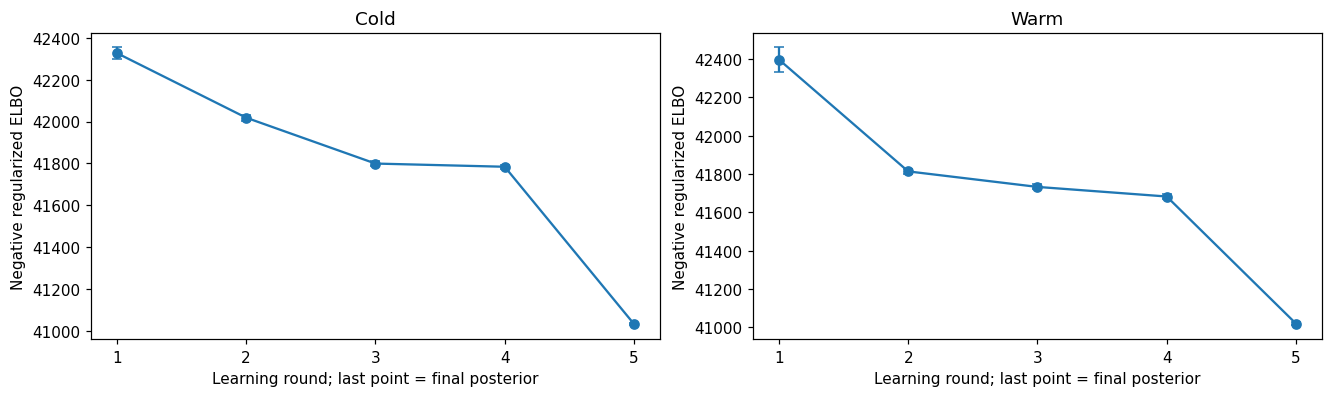

Cold: ELBO=-40872.28; regularized ELBO=-41033.10 +/- 6.29 (two MC standard errors)
Warm: ELBO=-40897.65; regularized ELBO=-41019.89 +/- 8.69 (two MC standard errors)


In [3]:
index = 0  # Which simulation to inspect.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), layout="constrained")
for ax, result, title in zip(axes, [cold_results[index], warm_results[index]], ["Cold", "Warm"]):
    estimates = result.history_elbo
    ax.errorbar(
        range(1, len(estimates) + 1), [e.loss for e in estimates],
        yerr=[2 * e.regularized_standard_error for e in estimates], marker="o", capsize=3,
    )
    ax.set(title=title, xlabel="Learning round; last point = final posterior", ylabel="Negative regularized ELBO")
    ax.set_xticks(range(1, len(estimates) + 1))
plt.show()

for name, result in [("Cold", cold_results[index]), ("Warm", warm_results[index])]:
    e = result.elbo_estimate
    print(f"{name}: ELBO={e.elbo:.2f}; regularized ELBO={e.regularized_elbo:.2f} "
          f"+/- {2*e.regularized_standard_error:.2f} (two MC standard errors)")

## 3. Compare reconstruction and loadings

Each run appears once in each result list. Reconstruction uses the posterior
average of products, `result.reconstruction`, rather than `result.L @ result.F.T`.
The seven generating programs have only four distinct sample profiles, so recovering
the original seven loading columns is not identifiable from this signal alone.

Seed    Cold RMSE    Warm RMSE
   1    0.16542      0.16642
Mean cold RMSE: 0.16542277449882697
Mean warm RMSE: 0.1664211405852219


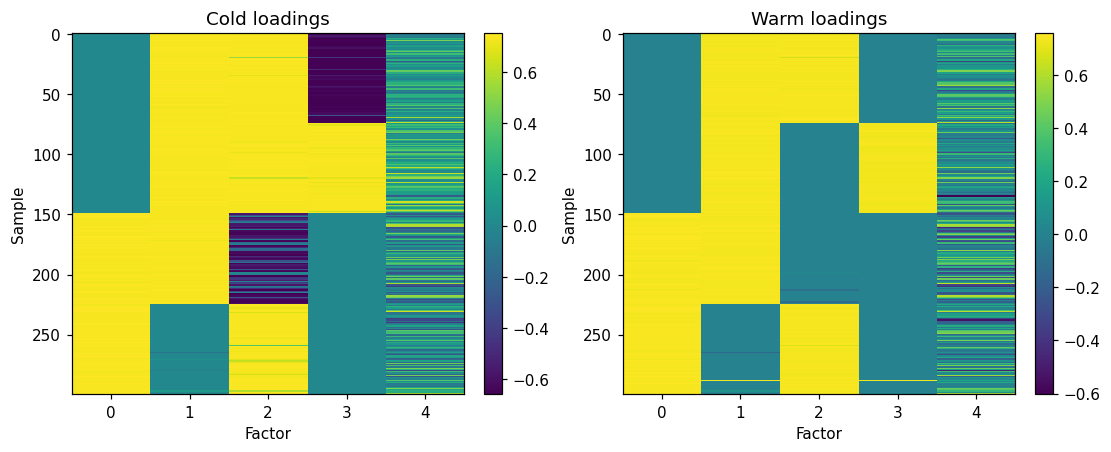

In [4]:
print("Seed    Cold RMSE    Warm RMSE")
for seed, cold_error, warm_error in zip(SEEDS, cold_rmse, warm_rmse):
    print(f"{seed:4d}    {cold_error:.5f}      {warm_error:.5f}")
print("Mean cold RMSE:", sum(cold_rmse) / len(cold_rmse))
print("Mean warm RMSE:", sum(warm_rmse) / len(warm_rmse))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
for ax, result, title in zip(axes, [cold_results[index], warm_results[index]], ["Cold loadings", "Warm loadings"]):
    picture = ax.imshow(result.L.detach().cpu(), aspect="auto", interpolation="nearest", cmap="viridis")
    ax.set(title=title, xlabel="Factor", ylabel="Sample")
    fig.colorbar(picture, ax=ax)
plt.show()